## Import Necessary Libraries

In [ ]:
# Lightweight path setup for local Jupyter, VS Code, or Colab runs.
# It keeps the notebook runnable whether you start it from this folder or the repo root.
from pathlib import Path
import os

FOLDER_NAME = '08-Custom-Loss-Functions'
NOTEBOOK_NAME = 'Project_02_Creating Custom Loss Function_TFlow.ipynb'

candidates = [
    Path.cwd(),
    Path.cwd() / FOLDER_NAME,
    Path.cwd() / "10-deep_learning" / FOLDER_NAME,
    Path.cwd().parent / FOLDER_NAME,
    Path.cwd().parent / "10-deep_learning" / FOLDER_NAME,
]

for candidate in candidates:
    if (candidate / NOTEBOOK_NAME).exists():
        os.chdir(candidate)
        break

print("Working directory:", Path.cwd().resolve())


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')

In [8]:
data = pd.read_csv("Regression_Data.csv")

In [9]:
data

,Ind_Data,Dependent_Data
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [10]:
X = data['Ind_Data'].values.reshape(-1,1)
X

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5]])

In [11]:
y = data['Dependent_Data'].values.reshape(-1,1)
y

array([[ 39343],
       [ 46205],
       [ 37731],
       [ 43525],
       [ 39891],
       [ 56642],
       [ 60150],
       [ 54445],
       [ 64445],
       [ 57189],
       [ 63218],
       [ 55794],
       [ 56957],
       [ 57081],
       [ 61111],
       [ 67938],
       [ 66029],
       [ 83088],
       [ 81363],
       [ 93940],
       [ 91738],
       [ 98273],
       [101302],
       [113812],
       [109431],
       [105582],
       [116969],
       [112635],
       [122391],
       [121872]])

In [ ]:
X.dtype

## Visualize the data

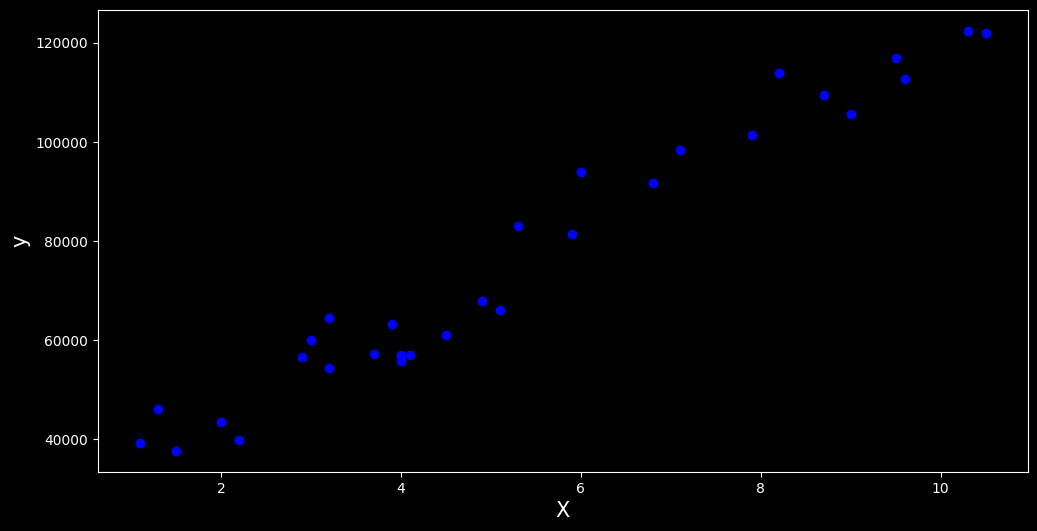

In [12]:
plt.figure(figsize =(12,6))
plt.scatter(X, y,color = 'b')
plt.ylabel('y', fontsize = 15)
plt.xlabel('X', fontsize = 15);

## Create Neural Network Model

In [13]:
model = Sequential()

model.add(Dense(units = 1, input_shape = (1,), activation = None)) # activations = None since the model is linear

# units = 1 means output dimension is one.
# input_shape = 1 means one input feature.

In [14]:
model.summary() # There are two parameters to train. One is weight and one is bias

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2 (8.00 Byte)
Trainable params: 2 (8.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# Creating Custom Loss Function

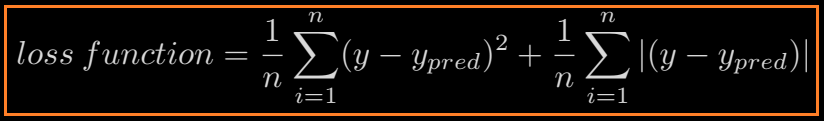

In [15]:
y = tf.cast(y, tf.float32) # Converting actual labels to tf.float32 for creating custom Loss function

In [16]:
def MyLoss_func(y, ypred):
    mse = tf.reduce_mean(tf.square(y - ypred))
    mae = tf.reduce_mean(tf.abs(y - ypred))
    return mse + mae

In [17]:
model.compile(optimizer = tf.keras.optimizers.SGD(learning_rate = 0.001) ,loss=MyLoss_func)

# Training the Neural Network

In [18]:
hist = model.fit(X,y, epochs = 500)  # try 5000 epochs

Epoch 1/500
1/1 [==============================] - 0s 463ms/step - loss: 6503286784.0000
Epoch 2/500
1/1 [==============================] - 0s 9ms/step - loss: 5602896384.0000
Epoch 3/500
1/1 [==============================] - 0s 12ms/step - loss: 4830168576.0000
Epoch 4/500
1/1 [==============================] - 0s 10ms/step - loss: 4167000064.0000
Epoch 5/500
1/1 [==============================] - 0s 8ms/step - loss: 3597855488.0000
Epoch 6/500
1/1 [==============================] - 0s 9ms/step - loss: 3109402368.0000
Epoch 7/500
1/1 [==============================] - 0s 10ms/step - loss: 2690198528.0000
Epoch 8/500
1/1 [==============================] - 0s 10ms/step - loss: 2330423808.0000
Epoch 9/500
1/1 [==============================] - 0s 8ms/step - loss: 2021651328.0000
Epoch 10/500
1/1 [==============================] - 0s 9ms/step - loss: 1756648832.0000
Epoch 11/500
1/1 [==============================] - 0s 8ms/step - loss: 1529209472.0000
Epoch 12/500
1/1 [=================

# Plotting Loss Vs Epochs

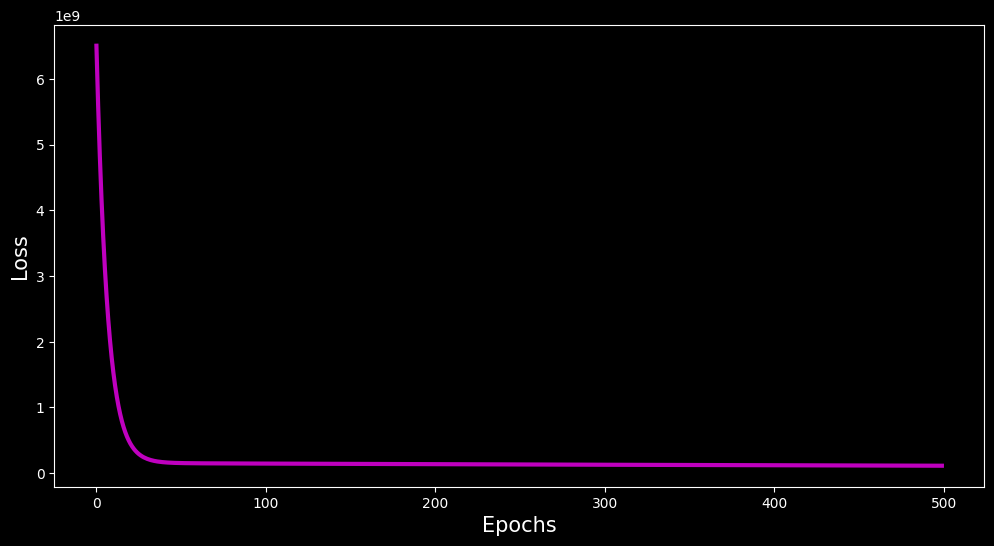

In [19]:
plt.figure(figsize =(12,6))
plt.plot(hist.history['loss'],'m', lw = 3, label= 'Training Loss')
plt.xlabel('Epochs', fontsize = 15)
plt.ylabel( 'Loss', fontsize = 15)
plt.show()

# Weight and Bias of the Trained Model

In [20]:
print("Weight is :" )
print(model.layers[0].get_weights()[0])

print(" ")

print("Bias is :" )
print(model.layers[0].get_weights()[1])

Weight is :
[[12316.019]]
 
Bias is :
[6478.645]


# Creating a test data

In [21]:
test_data = np.linspace(0,11,30).reshape(-1,1)

In [22]:
yt = model.predict(test_data)
yt

1/1 [==============================] - 0s 75ms/step


array([[  6478.645],
       [ 11150.238],
       [ 15821.832],
       [ 20493.424],
       [ 25165.018],
       [ 29836.611],
       [ 34508.203],
       [ 39179.797],
       [ 43851.39 ],
       [ 48522.984],
       [ 53194.58 ],
       [ 57866.17 ],
       [ 62537.76 ],
       [ 67209.36 ],
       [ 71880.95 ],
       [ 76552.55 ],
       [ 81224.14 ],
       [ 85895.734],
       [ 90567.33 ],
       [ 95238.92 ],
       [ 99910.516],
       [104582.1  ],
       [109253.7  ],
       [113925.3  ],
       [118596.88 ],
       [123268.48 ],
       [127940.08 ],
       [132611.67 ],
       [137283.25 ],
       [141954.84 ]], dtype=float32)

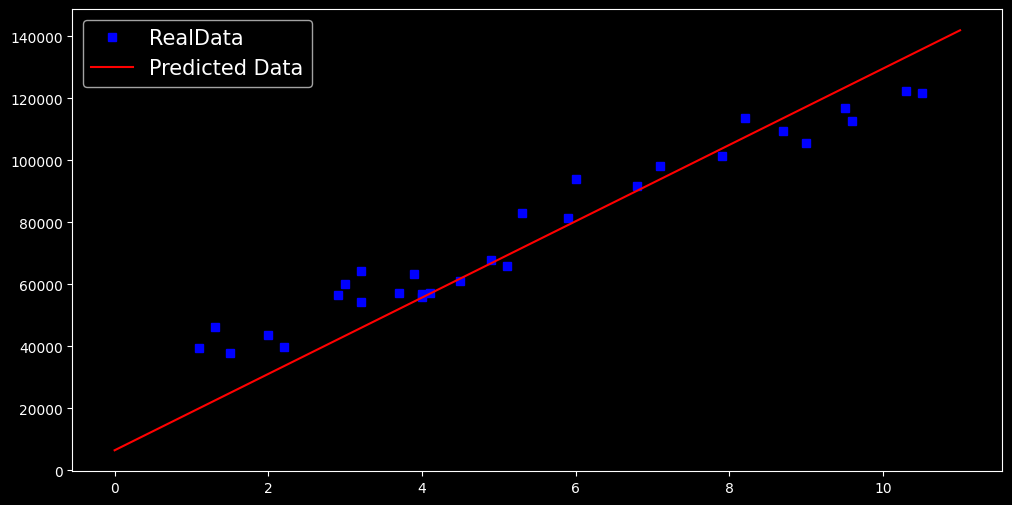

In [23]:
plt.figure(figsize =(12,6))
plt.plot(X, y,'bs',label = 'RealData')
plt.plot(test_data, yt, 'r', label = 'Predicted Data')
plt.legend(fontsize = 15)
plt.show()

# Check the Performance of the Model

In [24]:
from sklearn import metrics
print('RMSE:', np.sqrt(metrics.mean_squared_error(y, yt)))
print('MAE:', np.sqrt(metrics.mean_absolute_error(y, yt)))
print('R2:', metrics.r2_score(y, yt))

RMSE: 16441.357
MAE: 117.69665
R2: 0.6279167783548594
